# SPHEREx comet aperture photometry — end-to-end walkthrough

This notebook **runs and validates the production pipeline**, cell by cell, on the
sample data in `data/spherex_sample/`.  It calls exactly the same
`spherex_apphot.pipeline.run_target` that `scripts/apphot/main.py` runs in batch, so what you
check here is what the batch produces.

**Division of labour**

| | |
|---|---|
| `scripts/apphot/main.py` | photometry only — CSV, JSON sidecar, status log. **No figures.** |
| this notebook | the same pipeline, plus every figure and every validation check |

Sections
1. Setup and configuration
2. The cutout index and epoch grouping
3. Gaia reference field and sky coverage
4. Apertures: how the set is chosen per exposure
5. One cutout in detail — bad pixels, sky annulus, Gaia sources
6. Run the pipeline
7. Validation: growth curve, error budget, degenerate cases
8. Gaia contamination flags
9. **Does the flagging work?** — growth-curve contamination analysis
10. Spectra by flag
11. Reflectance
12. Band stacking and radial profiles
13. Saving the figure set
14. Provenance and the status log

## 1. Setup and configuration

In [1]:
import sys, warnings
from pathlib import Path

# The package lives at the project root (spherex-comet/spherex_apphot/).  Walk up
# from the kernel's cwd until it is found, wherever the kernel started; adding the
# root to sys.path is all that is needed (or `pip install -e .` once).
ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / "spherex_apphot" / "__init__.py").is_file())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spherex_apphot import Config, __version__, directory, plotting
from spherex_apphot.catalog import GaiaCatalog, NeighborIndex
from spherex_apphot.fitsio import FitsResolver, load_database, read_cutout
from spherex_apphot.logging_utils import setup_logging
from spherex_apphot.masking import build_badpix_mask
from spherex_apphot.pipeline import run_target, stack_target
from spherex_apphot.status import StatusLog

plotting.apply_rcparams()          # notebooks/rcparams.py, per project convention
%matplotlib inline
print("spherex_apphot", __version__)

spherex_apphot 2.2.0


/Users/bumhoo7/miniconda3/envs/spherex/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Use the production dataset on the external SSD when it is mounted, and fall
# back to the in-repo sample tree otherwise, so the notebook runs either way.
# Force one or the other by setting SAMPLE explicitly.
SAMPLE = not directory.DB_PATH.is_file()
if SAMPLE:
    directory.use_sample_data()
print("dataset:", "data/spherex_sample/" if SAMPLE else "production (T7)")
directory.ensure_dirs()

# Console logging only; scripts/apphot/main.py additionally writes a file into results/apphot/logs/.
setup_logging(None, level=20)
print(directory.describe())

dataset: production (T7)
  WORK_DIR       [ok     ] /Users/bumhoo7/Desktop/claude/spherex-comet-apphot
  DB_PATH        [ok     ] /Volumes/T7/data/spherex-comet/comets_v5/db_filtered.parq
  FITS_FILTERED_DIR [ok     ] /Volumes/T7/data/spherex-comet/comets_v5_fits_filtered
  FITS_ROOTS     [       ] /Volumes/T7/data/spherex-comet/comets_v5_fits_filtered:/Volumes/T7/data/spherex-comet/comets_v5_fits:/Users/bumhoo7/Desktop/claude/spherex-comet-apphot/data-sample
  GAIA_ALL_NPY   [ok     ] /Users/bumhoo7/Desktop/data/gaia_dr3/gaiadr3_all.npy
  GAIA_CACHE_DIR [ok     ] /Users/bumhoo7/Desktop/data/gaia_dr3/gaiadr3_deccache
  APPHOT_DIR     [ok     ] /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/results/apphot
  COMBFITS_DIR   [ok     ] /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/results/combined
  LOG_DIR        [ok     ] /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/results/logs
  FIG_DIR        [ok     ] /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig


In [3]:
cfg = Config()
cfg.validate()

print(f"config hash        : {cfg.hash}")
print(f"flux unit          : {cfg.flux_unit}")
print(f"sky annulus        : r_in={cfg.r_in_pix:g} px, r_out={cfg.r_out_pix:g} px  (fixed)")
print(f"aperture radii [km]: {[int(r) for r in cfg.aperture_radii_km]}")
print(f"aperture radii [px]: {cfg.aperture_radii_pix}")
print(f"error model        : sky_noise_mode={cfg.sky_noise_mode!r}")
print(f"epoch gap          : {cfg.epoch_gap_days:g} days")
print()
print(f"flag 'a'           : G_eff < {cfg.sourceflag_bright_gmag:g} within "
      f"r_ap + {cfg.sourceflag_bright_psf_mult:g}*FWHM")
print(f"flag 'b'           : Gaia flux > {cfg.sourceflag_b_flux_frac:g} x comet flux "
      f"within r_ap + {cfg.sourceflag_near_psf_mult:g}*FWHM")
print(f"stacking           : sigma-clipped {cfg.stack_combine}")
print(f"distance correction: flux {'/' if cfg.distcorr_mode == 'divide' else '*'}"
      f" (r_hel^2 * r_obs^2)")

config hash        : 5502194856bc
flux unit          : mJy/pixel
sky annulus        : r_in=15 px, r_out=20 px  (fixed)
aperture radii [km]: [10000, 12000, 14000, 16000, 18000, 20000, 22000, 24000, 26000, 28000, 30000, 32000, 34000, 36000, 38000, 40000, 60000, 80000, 100000]
aperture radii [px]: [2.0, 5.0]
error model        : sky_noise_mode='level'
epoch gap          : 28 days

flag 'a'           : G_eff < 13 within r_ap + 2*FWHM
flag 'b'           : Gaia flux > 0.2 x comet flux within r_ap + 1*FWHM
stacking           : sigma-clipped median
distance correction: flux * (r_hel^2 * r_obs^2)


The fixed 15–20 pixel annulus is the answer to review item **S2**.  The prototype
scaled the annulus to the *largest* aperture, which for a target closer than
~1.5 au put it outside the 91-pixel cutout entirely.  A fixed, close-in annulus
also matters because SPHEREx's central wavelength varies across the detector: a
distant annulus samples a different bandpass than the aperture it corrects.

**`flux_distcorr`** normalises every flux to a common geometry:

$$F_{\rm corr} = F \times r_{\rm hel}^2\, r_{\rm obs}^2$$

i.e. the flux the comet would have shown at $r_{\rm hel} = r_{\rm obs} = 1$ au.
Reflected light falls as $1/(r_{\rm hel}^2 r_{\rm obs}^2)$ — the illuminating
sunlight with heliocentric distance, the reflected light again with observer
distance — so this cancels the geometric dilution exactly and leaves a quantity
that is constant for an unchanging coma.  Whatever variation survives is real
activity.  §10 shows the effect on 24P's two epochs.

## 2. The cutout index and epoch grouping

In [4]:
TARGET = "24P"          # bright, nearby, crowded field — exercises every code path
db = load_database(directory.DB_PATH, objdesig=TARGET)
print(f"{len(db)} exposures, {db.shape[1]} index columns")
db[["filename", "obsid", "detector", "wl", "vmag", "r_hel", "r_obs",
    "pix_scale", "PSF_FWHM", "xcen", "ycen", "cutout_size"]].head()

2026-09-07 03:59:28 INFO    spherex_apphot.fitsio: loaded 765 rows from db_filtered.parq for objdesig='24P'


765 exposures, 240 index columns


,filename,obsid,detector,wl,vmag,r_hel,r_obs,pix_scale,PSF_FWHM,xcen,ycen,cutout_size
0,24P_0.7679um_18.84Vmag_2025W36_2B_0131_4_1.fits,2025W36_2B_0131_4,1,0.767881,18.844160,1.939799,1.825489,6.183615,5.254279,44.96875,44.71875,91
1,24P_2.4999um_18.84Vmag_2025W36_2B_0131_4_4.fits,2025W36_2B_0131_4,4,2.499914,18.844160,1.939799,1.825489,6.189610,6.104328,45.15625,44.71875,91
2,24P_0.7505um_18.84Vmag_2025W36_2B_0131_3_1.fits,2025W36_2B_0131_3,1,0.750503,18.844221,1.939812,1.825514,6.186833,5.254279,45.21875,45.21875,91
3,24P_2.4417um_18.84Vmag_2025W36_2B_0131_3_4.fits,2025W36_2B_0131_3,4,2.441700,18.844221,1.939812,1.825514,6.192779,6.104328,44.62500,45.12500,91
4,24P_1.0011um_18.84Vmag_2025W36_2B_0157_1_1.fits,2025W36_2B_0157_1,1,1.001144,18.838432,1.938653,1.823102,6.151236,5.254279,45.46875,44.59375,91


In [5]:
from spherex_apphot.epochs import epoch_table, group_epochs

work = group_epochs(db, gap_days=cfg.epoch_gap_days).rename(
    columns={"DATE-OBS": "date_obs", "PSF_FWHM": "psf_fwhm_arcsec"})
epoch_table(work, key_dateobs="date_obs")

2026-09-07 03:59:28 INFO    spherex_apphot.epochs: 765 exposures grouped into 2 epoch(s) at a 28-day gap


,epoch,n_exposures,date_start,date_end,wl_min,wl_max,r_hel_mean,r_obs_mean,alpha_mean,vmag_mean
0,1,363,2025-09-05 03:35:33.810000+00:00,2025-10-19 10:21:46.662000+00:00,0.743996,5.005084,1.780671,1.507576,34.309382,17.983895
1,2,402,2025-11-20 18:08:43.385000+00:00,2026-02-03 00:57:10.145000+00:00,1.119226,5.005276,1.200018,0.603799,54.762279,14.094255


The column is called **`epoch`**, not `phase`.  The index already carries `alpha`,
the solar *phase angle* — the standard meaning of "phase" in comet photometry — so
the prototype's name was a collision waiting to mislead someone.

## 3. Gaia reference field and sky coverage

In [6]:
gaia_cat = GaiaCatalog(cache_dir=directory.GAIA_CACHE_DIR, src_npy=directory.GAIA_ALL_NPY)
print("backend:", gaia_cat.mode)

%time subset = gaia_cat.cone_search(work["ra"], work["dec"], \
                                    radius_deg=cfg.gaia_search_radius_deg, \
                                    gmag_limit=cfg.gaia_gmag_limit)
print(subset)

2026-09-07 03:59:28 INFO    spherex_apphot.catalog: Gaia: declination cache /Users/bumhoo7/Desktop/data/gaia_dr3/gaiadr3_deccache (419445290 rows)


backend: cache


CPU times: user 17.6 s, sys: 530 ms, total: 18.1 s
Wall time: 18.5 s
GaiaSubset(n=76681, G=6.11-18.50)


`mode='cache'` means the declination-sorted cache built by `build_gaia_cache.py`
is in use: the query binary-searches a memory map and reads only the relevant
declination band.  Without it the same query falls back to a full pass over the
11.7 GB catalogue — about 21 s instead of 0.2 s, **per target**.  The prototype
paid that full pass once per target *and* spawned a subprocess per target, so a
445-target run read the catalogue 445 times (review items **P1**, **P2**, **P5**).

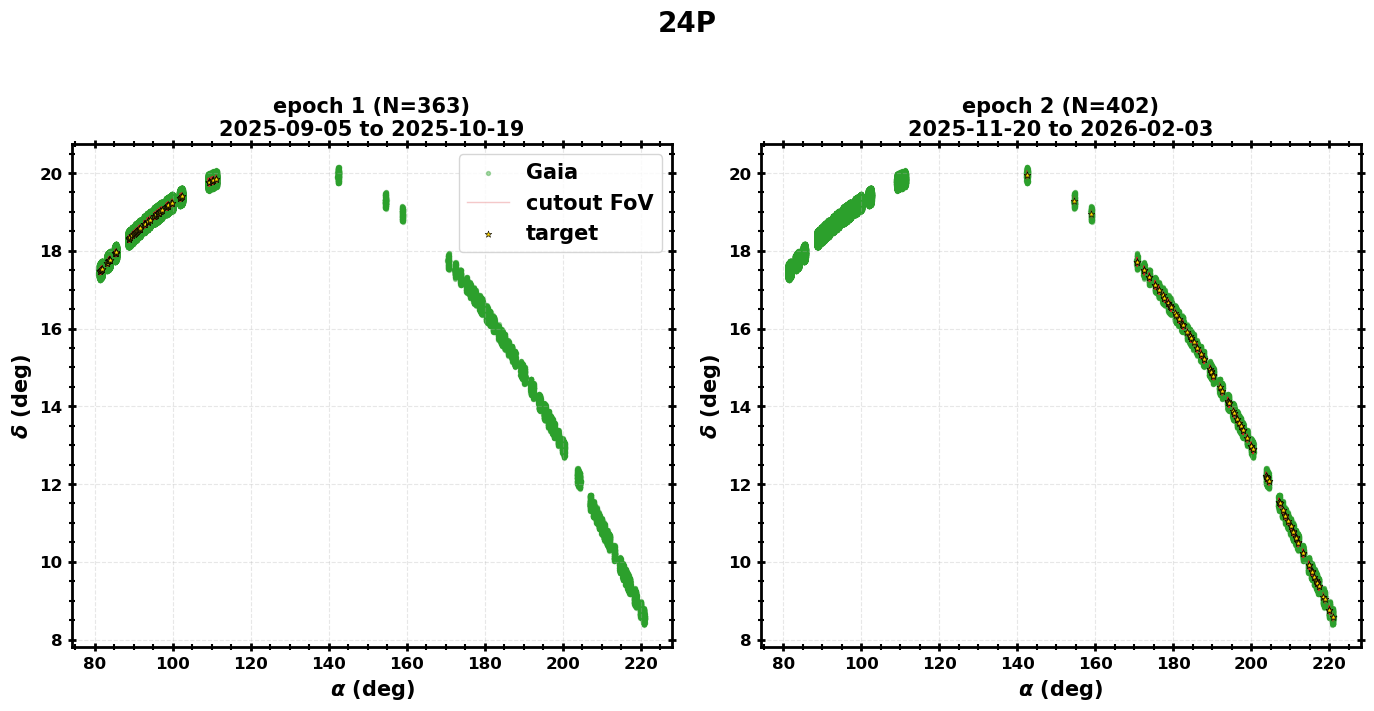

In [7]:
fig = plotting.plot_coverage(work, gaia=subset, objdesig=TARGET)
plt.show()

## 4. Apertures: how the set is chosen per exposure

Aperture radii are specified in **km at the comet**, so the same physical region
is measured whatever the geometry — but that means the pixel radius changes with
every exposure.  An aperture is used only when

$$\mathrm{PSF_{FWHM}} \le r_\mathrm{ap} < r_\mathrm{in}$$

Below the PSF the flux is neither resolved nor correctable; at or beyond $r_{in}$
the aperture would overlap its own background.  Two fixed-pixel apertures (2 px,
5 px) are always measured as a distance-independent reference.

In [8]:
from spherex_apphot.apertures import build_apertures, pixel_scale_km

row = work.iloc[0]
fwhm_pix = float(row["psf_fwhm_arcsec"]) / float(row["pix_scale"])
kmpp = pixel_scale_km(float(row["pix_scale"]), float(row["r_obs"]))
print(f"r_obs = {row['r_obs']:.2f} au -> {kmpp:.0f} km/pixel; "
      f"PSF FWHM = {row['psf_fwhm_arcsec']:.2f}\" = {fwhm_pix:.2f} px")

specs = build_apertures(cfg, pix_scale_arcsec=float(row["pix_scale"]),
                        r_obs_au=float(row["r_obs"]), psf_fwhm_pix=fwhm_pix)
pd.DataFrame([{"label": s.label, "kind": s.kind, "r_ap_pix": round(s.r_ap_pix, 3),
               "r_ap_km": s.r_ap_km, "valid": s.valid, "why": s.reject_reason}
              for s in specs])

r_obs = 1.83 au -> 8191 km/pixel; PSF FWHM = 5.25" = 0.85 px


,label,kind,r_ap_pix,r_ap_km,valid,why
0,km10000,km,1.221,10000.000000,True,
1,km12000,km,1.465,12000.000000,True,
2,km14000,km,1.709,14000.000000,True,
3,km16000,km,1.953,16000.000000,True,
4,km18000,km,2.197,18000.000000,True,
5,km20000,km,2.442,20000.000000,True,
6,km22000,km,2.686,22000.000000,True,
7,km24000,km,2.930,24000.000000,True,
8,km26000,km,3.174,26000.000000,True,
9,km28000,km,3.418,28000.000000,True,


## 5. One cutout in detail

In [9]:
resolver = FitsResolver(directory.FITS_ROOTS)
path = resolver.find(row["filename"], TARGET)
cut = read_cutout(path)
print(path.name)
print(f"planes: sci {cut.sci.shape} {cut.sci.dtype}, var {cut.var.dtype}, flag {cut.flag.dtype}")

badpix, report = build_badpix_mask(cut.sci, cut.var, cut.flag, cfg.bad_flag_bits,
                                   mask_nonfinite_sci=cfg.mask_nonfinite_sci,
                                   mask_bad_variance=cfg.mask_bad_variance)
report

24P_0.7505um_18.84Vmag_2025W36_2B_0131_3_1.fits
planes: sci (91, 91) float64, var float64, flag uint32


{'n_flag': 28,
 'n_nonfinite_sci': 0,
 'n_bad_var': 0,
 'n_badpix': 28,
 'frac_badpix': 0.0033812341504649195}

Note `n_nonfinite_sci`: roughly a sixth of the science pixels are NaN and **none
of them carries a flag bit**.  Relying on the flag plane alone, as the prototype
did, leaks NaN straight into the aperture sums.  Bad variance is caught for the
same reason — a zero variance contributes zero uncertainty and inflates the SNR
(review item **R5**).

Extensions are addressed by `EXTNAME`, not position (review item **R2**).

### The three-panel cutout view

Raw science, the FLAG plane, and the masked science with **every catalogued Gaia
source marked** — circle area proportional to Gaia *flux*, so brightness is
visible at a glance, annotated with G magnitude.  The red circle is the
photometric aperture, the dashed blue pair the fixed sky annulus.

Gaia stars are **not** masked.  The prototype painted a disc over every source
with a radius that grew with stellar brightness, deleting real coma flux wherever
a star happened to lie near the comet.  This panel is where a blend becomes
visible instead.

569 Gaia sources projected into this cutout


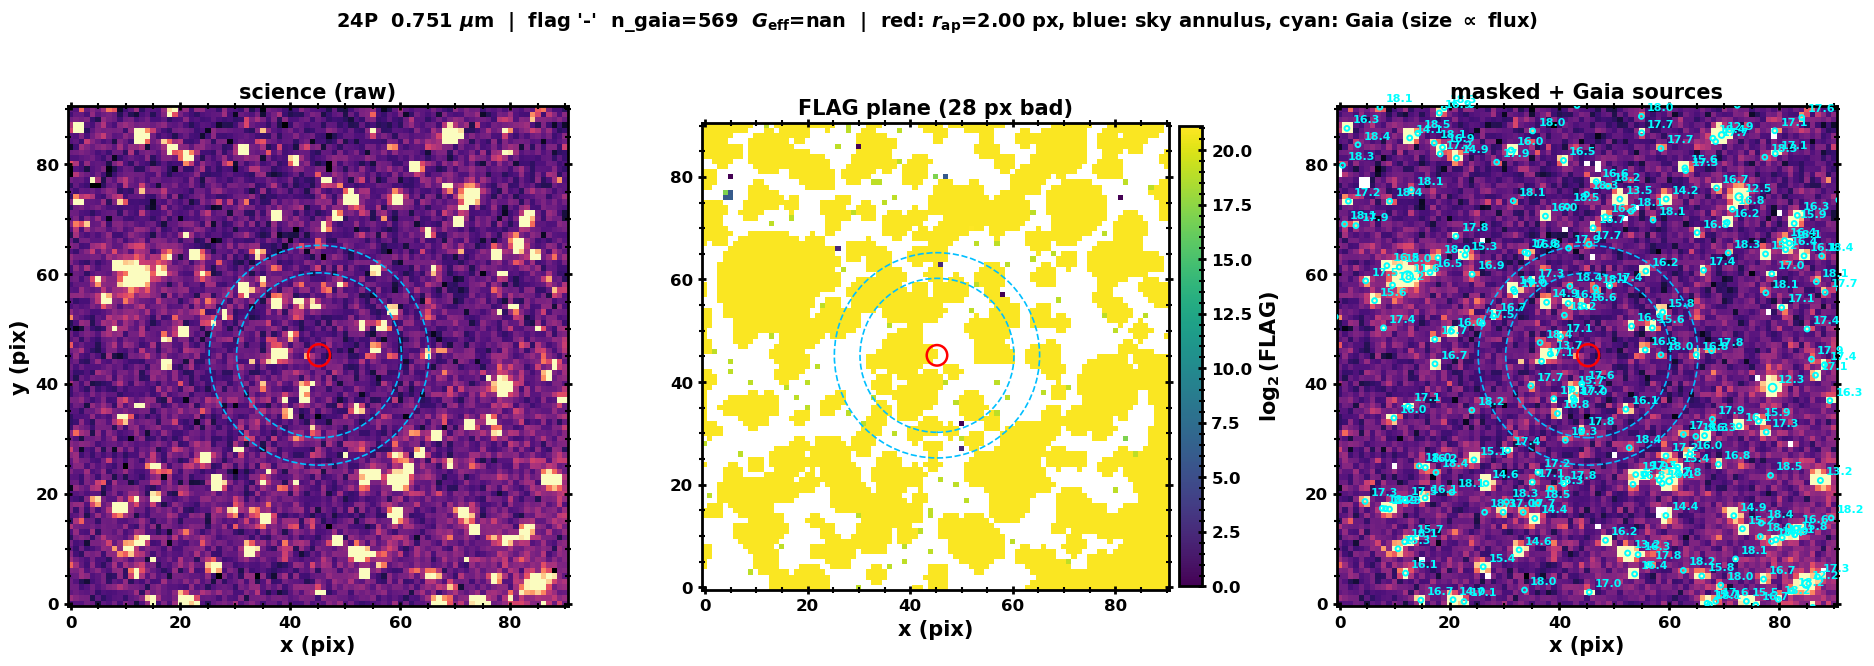

In [10]:
from spherex_apphot.sourceflag import project_gaia
from spherex_apphot.wcsutil import wcs_from_header

neighbors = NeighborIndex(subset)
ny, nx = cut.sci.shape
rad_deg = (0.5 * np.hypot(nx, ny) + 30.0) * float(row["pix_scale"]) / 3600.0
near = neighbors.query(float(row["ra"]), float(row["dec"]), rad_deg)
field = project_gaia(near, wcs_from_header(cut.header),
                     float(row["xcen"]), float(row["ycen"]), cut.sci.shape)
print(f"{len(field)} Gaia sources projected into this cutout")

fig = plotting.plot_cutout_with_gaia(
    cut, badpix, row.to_dict() | {"r_ap_pix": 2.0, "sourceflag": "-",
                                  "n_gaia": len(field), "gmag_eff": np.nan},
    field, cfg, objdesig=TARGET, r_ap_pix=2.0)
plt.show()

In [11]:
from spherex_apphot.phot import estimate_sky
sky = estimate_sky(cut.sci, cut.var, badpix, float(row["xcen"]), float(row["ycen"]), cfg)
print(sky)
print(f"sky_excess_ratio = {sky.excess_ratio:.3f}")
print("  (annulus scatter / scatter predicted by the variance plane;")
print("   > 1 means the variance plane is optimistic)")

SkyEstimate(median=0.3912, std=0.02558, area=518.1, ok=True)
sky_excess_ratio = 1.148
  (annulus scatter / scatter predicted by the variance plane;
   > 1 means the variance plane is optimistic)


## 6. Run the pipeline

In [12]:
status = StatusLog(directory.STATUS_CSV)

res = run_target(TARGET, cfg,
                 gaia=gaia_cat,          # reuse the open catalogue
                 status=status,
                 write=True)

print(f"status   : {res.status}")
print(f"elapsed  : {res.elapsed_s:.1f} s")
print(f"output   : {res.output_csv}")
for k, v in res.counters.items():
    print(f"  {k:<18s} {v}")

2026-09-07 03:59:52 INFO    spherex_apphot.fitsio: loaded 765 rows from db_filtered.parq for objdesig='24P'


2026-09-07 03:59:52 INFO    spherex_apphot.epochs: 765 exposures grouped into 2 epoch(s) at a 28-day gap


2026-09-07 04:00:12 INFO    spherex_apphot.pipeline: 24P: 765 exposures, 2 epoch(s), 76681 Gaia source(s) G<18.5


2026-09-07 04:00:20 INFO    spherex_apphot.pipeline:   24P: 200/765 exposures


2026-09-07 04:00:29 INFO    spherex_apphot.pipeline:   24P: 400/765 exposures


2026-09-07 04:00:38 INFO    spherex_apphot.pipeline:   24P: 600/765 exposures


2026-09-07 04:00:45 INFO    spherex_apphot.pipeline: 24P: 14526 rows (765 exposures x apertures), 8038 flagged badphot


2026-09-07 04:00:46 INFO    spherex_apphot.pipeline: wrote /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/results/apphot/24P.csv (14526 rows) and 24P.meta.json


status   : ok
elapsed  : 53.9 s
output   : /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/results/apphot/24P.csv
  n_exposures        765
  n_epochs           2
  n_gaia             76681
  n_exposures_ok     765
  n_missing_fits     0
  n_read_errors      0
  n_ap_skipped       1539
  n_rows_out         14526
  n_badphot          8038


In [13]:
phot = res.phot
print(phot.shape)
print("distance-corrected columns:", [c for c in phot.columns if "distcorr" in c])
phot.head(3).T.head(45)

(14526, 73)
distance-corrected columns: ['flux_distcorr_mjy', 'flux_distcorr_err_mjy', 'distcorr_factor']


,0,1,2
filename,24P_0.7505um_18.84Vmag_2025W36_2B_0131_3_1.fits,24P_0.7505um_18.84Vmag_2025W36_2B_0131_3_1.fits,24P_0.7505um_18.84Vmag_2025W36_2B_0131_3_1.fits
objdesig,24P,24P,24P
obsid,2025W36_2B_0131_3,2025W36_2B_0131_3,2025W36_2B_0131_3
detector,1,1,1
epoch,1,1,1
wl,0.750503,0.750503,0.750503
ap_label,km10000,km12000,km14000
ap_kind,km,km,km
r_ap_pix,1.220805,1.464966,1.709126
r_ap_km,10000.0,12000.0,14000.0


## 7. Validation

### 7a. Growth curve

For a real extended coma the enclosed flux must **increase monotonically** with
aperture radius, and the *annulus surface brightness* must **fall** outward.
Together these are the single most informative sanity check on the whole chain:
they fail if the sky is over-subtracted, if the centroid is wrong, or if the
aperture areas are mis-computed — and, as §9 shows, they are also how a field
star gives itself away.

exposure (clean): 24P_0.9996um_18.71Vmag_2025W37_1A_0081_2_1.fits


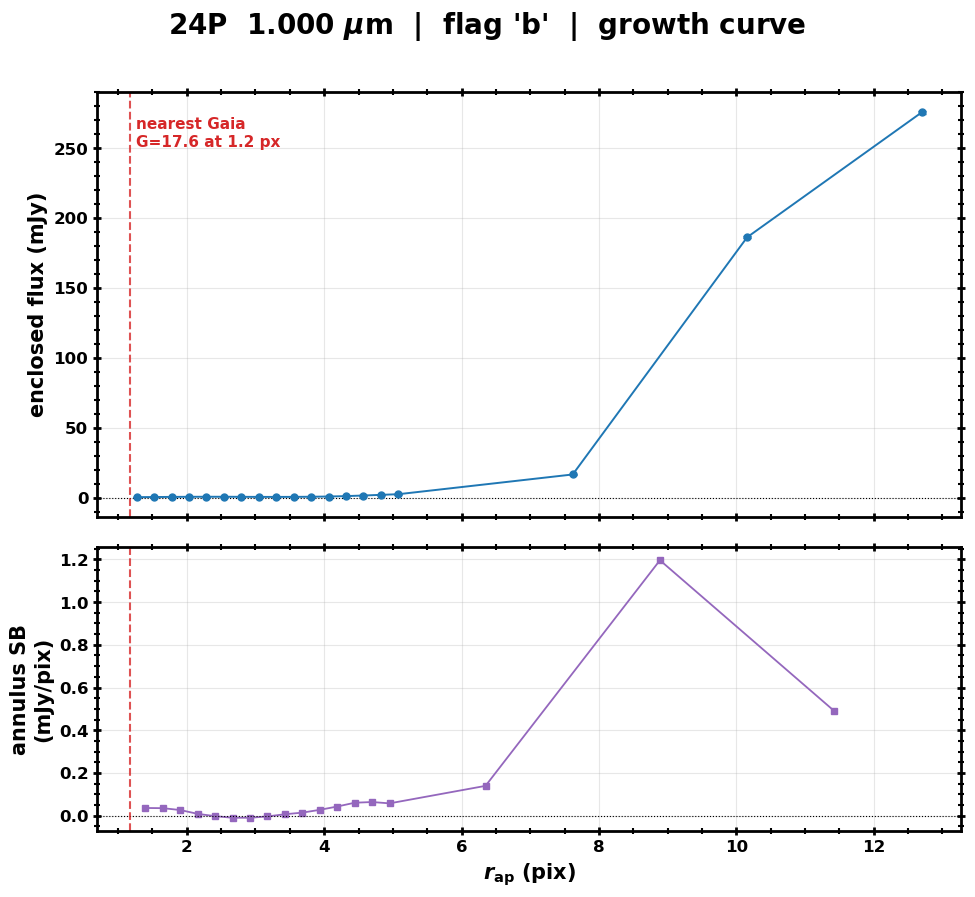

steps increasing        : 14/18
most significant decrease: -0.26 sigma  (noise if > -3)


In [14]:
# Pick a well-detected exposure that is free of both bad pixels and Gaia
# contamination across all of its km apertures, so the curve shows the coma
# alone.  Filtering on SNR before choosing the exposure would truncate it.
km = phot[phot.ap_kind == "km"]
per_file = km.groupby("filename").agg(
    bad=("badphot", "any"),
    contaminated=("sourceflag", lambda s: (s.astype(str) != "0").any()))
for mask, why in [(~per_file.bad & ~per_file.contaminated, "clean + uncontaminated"),
                  (~per_file.bad, "clean"),
                  (per_file.bad.notna(), "any")]:
    names = per_file.index[mask]
    if len(names):
        break
pool = km[km.filename.isin(names)]
best = pool.groupby("filename").snr.max().idxmax()
one = phot[phot.filename == best]
print(f"exposure ({why}): {best}")

fig = plotting.plot_growth_curve(one, objdesig=TARGET)
plt.show()

g = one[one.ap_kind == "km"].sort_values("r_ap_pix")
d = np.diff(g.source_sum_mjy.values)
e = g.source_sum_err_mjy.values
sig = d / np.sqrt(e[1:]**2 + e[:-1]**2)
print(f"steps increasing        : {int((d > 0).sum())}/{len(d)}")
print(f"most significant decrease: {sig.min():+.2f} sigma  (noise if > -3)")

### 7b. Error budget — the S6 double count

The variance plane already contains the background's photon noise, so DAOPHOT's
$A\,\sigma_{sky}^2$ term counts it a second time.  The default `sky_noise_mode`
keeps the propagated pixel variance and the uncertainty on the *subtracted sky
level*, and drops the duplicate.  Every component is reported separately.

In [15]:
comp = phot[["err_pix_mjy", "err_skylevel_mjy", "err_skyscatter_mjy",
             "source_sum_err_mjy", "source_sum_err_empirical_mjy"]]
display(comp.median().rename("median (mJy)").to_frame())

daophot = np.sqrt(phot.err_pix_mjy**2 + phot.err_skyscatter_mjy**2 + phot.err_skylevel_mjy**2)
ratio = (phot.source_sum_err_mjy / daophot).median()
print(f"default / double-counted error = {ratio:.3f}  ({100*(1-ratio):.0f} % smaller)")
print(f"median sky_excess_ratio        = {phot.sky_excess_ratio.median():.3f}")

,median (mJy)
err_pix_mjy,0.326899
err_skylevel_mjy,0.186481
err_skyscatter_mjy,0.401740
source_sum_err_mjy,0.403300
source_sum_err_empirical_mjy,0.459746


default / double-counted error = 0.758  (24 % smaller)
median sky_excess_ratio        = 1.450


**Read `sky_excess_ratio` before trusting the error bars.**  A value well above 1
means the variance plane under-reports the real pixel-to-pixel scatter (confusion,
zodiacal structure, flat-field residuals it does not model).  Where that happens,
`source_sum_err_mjy` is a *lower bound* and `source_sum_err_empirical_mjy` — built
from the measured annulus scatter alone — is the more honest number.

### 7c. Bad pixels, degenerate cases, and the distance correction

In [16]:
chk = phot.assign(area_lost=phot.aperture_area_pix2 - phot.aperture_area_eff_pix2)
print("area accounting  : max |A_geom - A_eff - badpix_area| = "
      f"{(chk.area_lost - chk.badpix_area_ap_pix2).abs().max():.2e} pix^2")
print("badphot == (badpix in aperture): "
      f"{bool((chk.badphot == ((chk.badpix_area_ap_pix2 > 0) | (chk.aperture_area_eff_pix2 <= 0))).all())}")
print("bad pixel in the annulus only  : "
      f"{int(((chk.n_badpix_sky > 0) & ~chk.badphot).sum())} rows (correctly not flagged)")

neg = phot[phot.source_sum_mjy < 0]
print(f"\nnegative fluxes kept: {len(neg)} rows (S5)")
print(f"  abmag undefined there: {bool(neg.abmag.isna().all())}")
print(f"  errors still finite  : {bool(neg.source_sum_err_mjy.notna().all())}")

deg = phot[phot.aperture_area_eff_pix2 <= 0]
print(f"\nfully-masked apertures: {len(deg)}  all flagged badphot: {bool(deg.badphot.all())}")

ok = phot.dropna(subset=["flux_distcorr_mjy", "source_sum_mjy"])
expect = ok.source_sum_mjy * ok.r_hel**2 * ok.r_obs**2      # normalised to 1 au
rel = (np.abs(expect - ok.flux_distcorr_mjy) / np.abs(expect).clip(1e-30)).max()
print(f"\ndistance correction: max relative error = {rel:.2e}")
print("  (the CSV is written with %.8g, so ~1e-7 is round-trip precision, "
      "not a computation error)")

area accounting  : max |A_geom - A_eff - badpix_area| = 1.14e-13 pix^2
badphot == (badpix in aperture): True
bad pixel in the annulus only  : 6228 rows (correctly not flagged)

negative fluxes kept: 524 rows (S5)
  abmag undefined there: True
  errors still finite  : True

fully-masked apertures: 73  all flagged badphot: True

distance correction: max relative error = 3.01e-16
  (the CSV is written with %.8g, so ~1e-7 is round-trip precision, not a computation error)


### 7d. WCS cross-check

In [17]:
from spherex_apphot.wcsutil import compare_wcs, reconstruct_cutout_wcs

worst = 0.0
for r in work.head(25).itertuples(index=False):
    p = resolver.find(getattr(r, "filename"), TARGET)
    if p is None:
        continue
    c = read_cutout(p)
    mx, _ = compare_wcs(wcs_from_header(c.header), reconstruct_cutout_wcs(r), c.sci.shape)
    worst = max(worst, mx)
print(f"max header-vs-reconstructed disagreement over 25 cutouts: {worst:.2e} pixels")

max header-vs-reconstructed disagreement over 25 cutouts: 5.22e-07 pixels


### 7e. Aperture acceptance

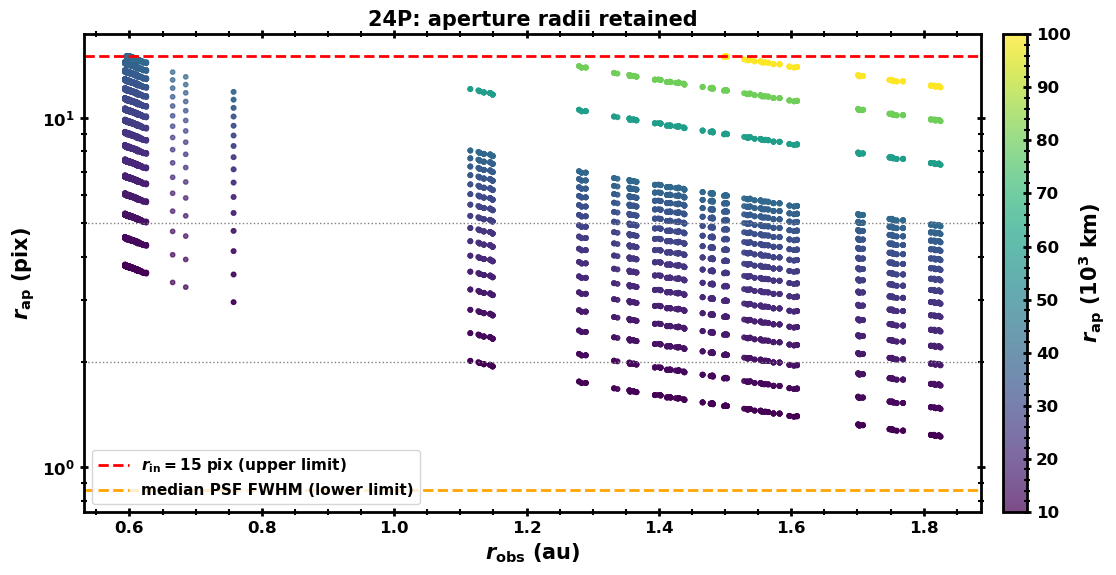

In [18]:
fig = plotting.plot_aperture_validity(phot, cfg, objdesig=TARGET)
plt.show()

## 8. Gaia contamination flags

| flag | condition | marker |
|---|---|---|
| `a` | combined $G$ inside $r_{ap} + 2\,\mathrm{FWHM}$ brighter than **13** | ▲ |
| `b` | Gaia flux inside $r_{ap} + \mathrm{FWHM}$ exceeds **20 %** of the comet's own flux | ▼ |
| `c` | any source inside $r_{ap} + \mathrm{FWHM}$ | ■ |
| `d` | $\mathrm{SNR} < 1$ | ◆ |
| `0` | none of the above | ● |
| `badphot` | a bad pixel inside the aperture (data quality, not contamination) | ✕ |

Only the highest-priority flag is stored (`a` > `b` > `c` > `d` > `0`).  Blends
are summed in flux, so two $G=15$ stars give $G_{eff}=14.25$.

`a` and `b` are **not nested** — they ask different questions.  `a` is absolute:
is there a bright star nearby at all, within a generous $r_{ap}+2\,$FWHM, whose
wings will contaminate the aperture regardless of the comet.  `b` is relative:
inside the tighter $r_{ap}+$FWHM, do the blended stars matter *compared with this
comet*.  In flux terms `b` fires when

$$10^{-0.4 G_{eff}} > 0.2 \times 10^{-0.4 V},\quad\text{i.e.}\quad G_{eff} < V + 1.75$$

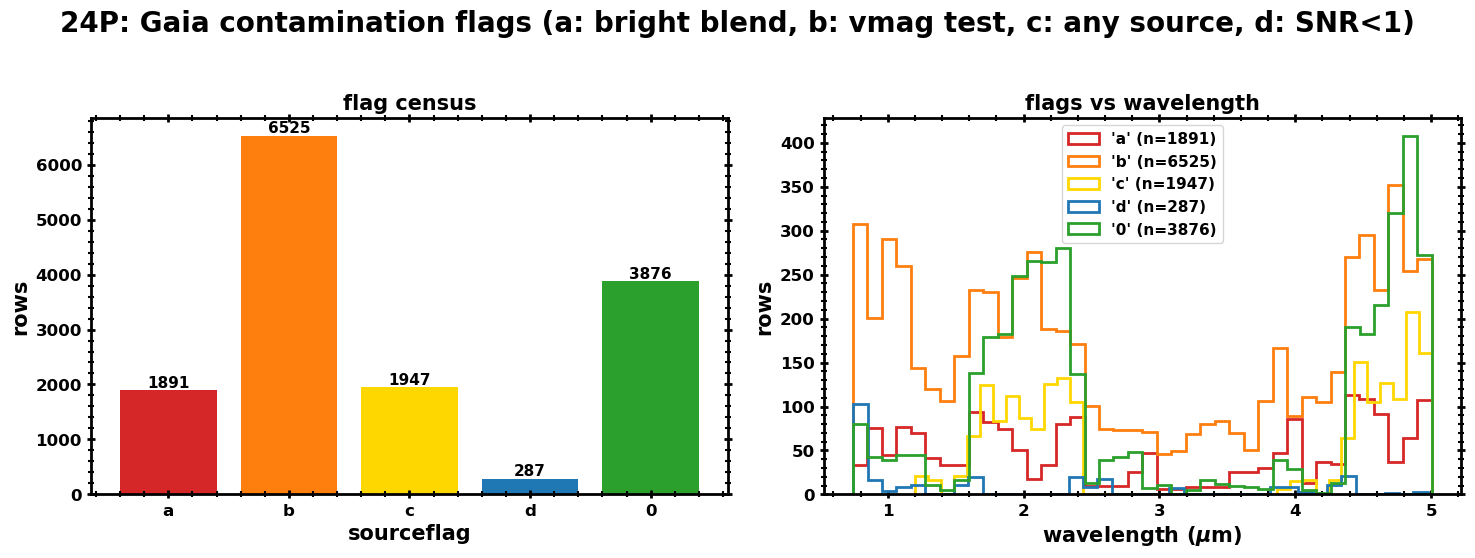

,rows
sourceflag,
b,6525
0,3876
c,1947
a,1891
d,287


In [19]:
fig = plotting.plot_sourceflag_summary(phot, objdesig=TARGET)
plt.show()
phot.sourceflag.astype(str).value_counts().rename("rows").to_frame()

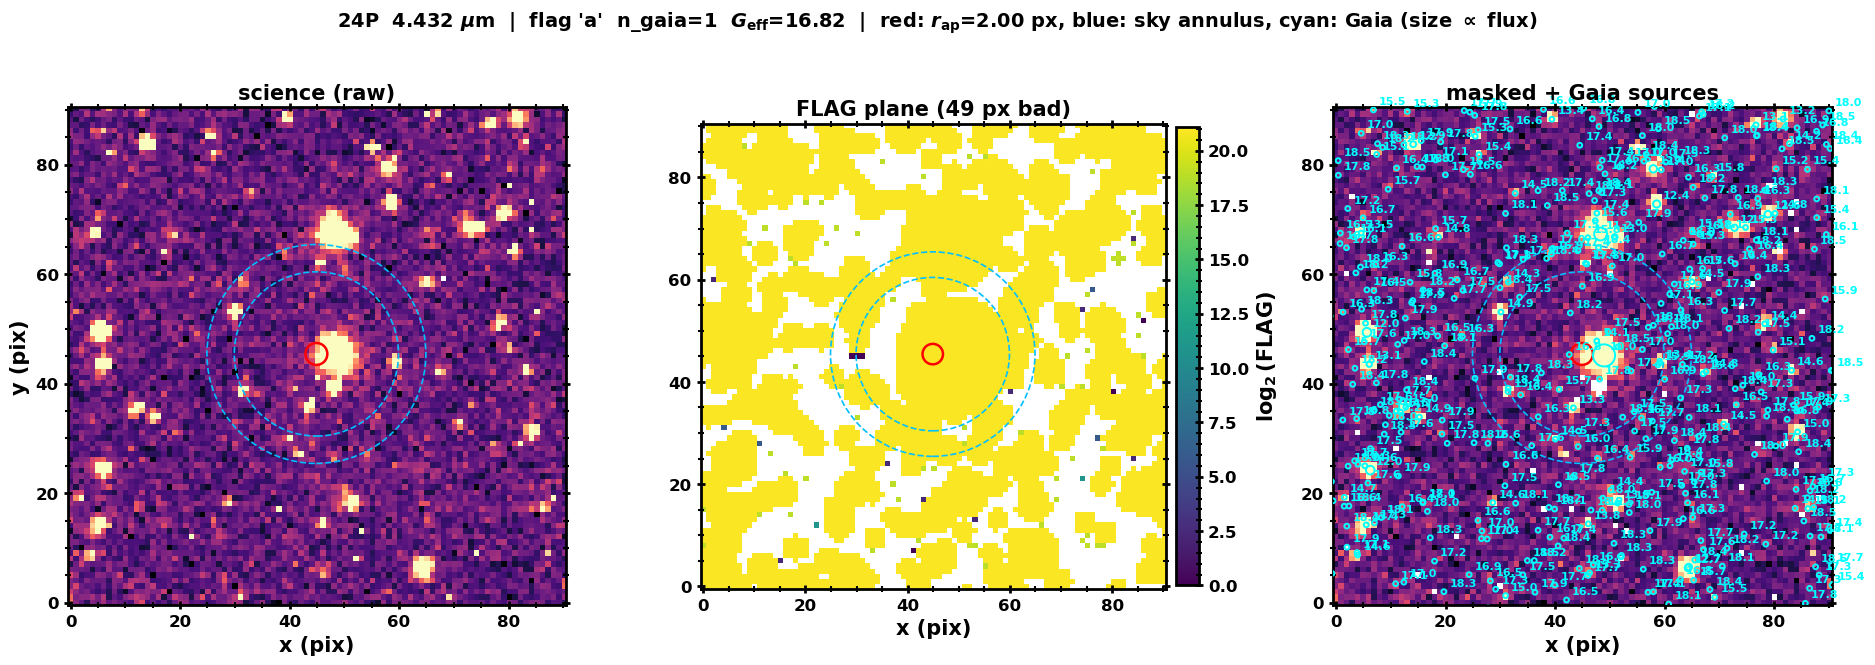

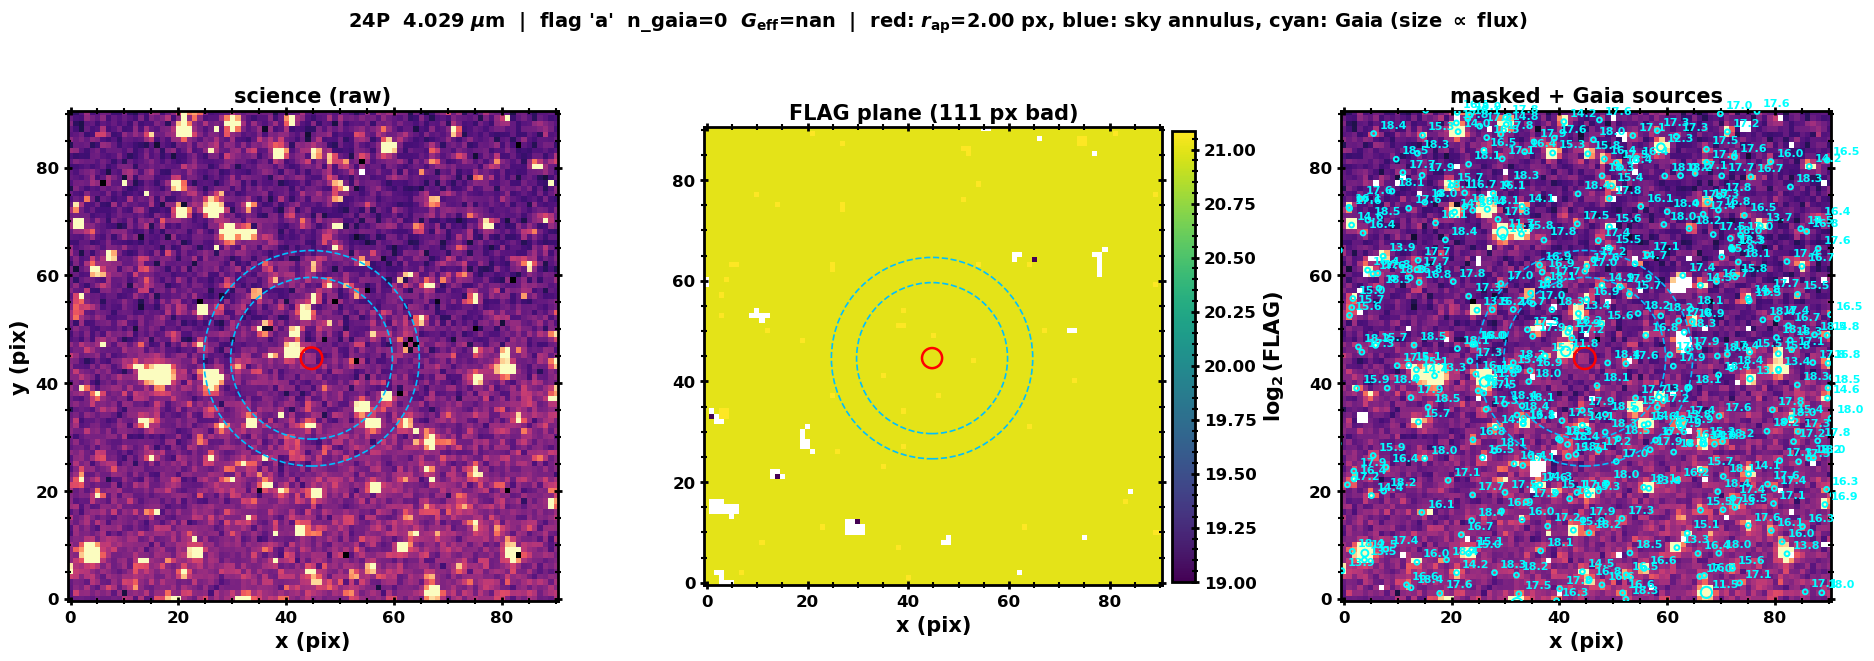

In [20]:
# The worst blends: 'a'-flagged cutouts, brightest first.
AP = "pix02.0"
worst_rows = phot[(phot.ap_label == AP) & (phot.sourceflag == "a")] \
             .sort_values("gmag_eff_bright").head(2)
for r in worst_rows.itertuples(index=False):
    p = resolver.find(r.filename, TARGET)
    c = read_cutout(p)
    bp, _ = build_badpix_mask(c.sci, c.var, c.flag, cfg.bad_flag_bits,
                              mask_nonfinite_sci=cfg.mask_nonfinite_sci,
                              mask_bad_variance=cfg.mask_bad_variance)
    ny, nx = c.sci.shape
    rd = (0.5 * np.hypot(nx, ny) + 30.0) * float(r.pix_scale) / 3600.0
    f = project_gaia(neighbors.query(float(r.ra), float(r.dec), rd),
                     wcs_from_header(c.header), float(r.xcen), float(r.ycen), c.sci.shape)
    fig = plotting.plot_cutout_with_gaia(c, bp, r, f, cfg, objdesig=TARGET,
                                         r_ap_pix=float(r.r_ap_pix))
    plt.show()

## 9. Does the flagging work?

A flag that never fires is useless; one that fires on everything is equally
useless.  Neither failure is visible unless the flags are tested against an
**independent** symptom of contamination.  The growth curve supplies one.

Differentiate the growth curve and you get each annulus's mean surface
brightness.  For a steady-state coma this falls monotonically outward
($\Sigma \propto 1/\rho$).  A field star entering the aperture at some radius
makes it **rise** instead — a signature no coma model produces.
`diagnostics.growth_metrics` measures the most significant such rise per
exposure, in units of its own uncertainty, and calls anything above $3\sigma$
contaminated.

In [21]:
from spherex_apphot.diagnostics import (contamination_summary, flag_effectiveness,
                                        growth_metrics)

metrics = growth_metrics(phot, ap_kind="km")
print(f"{len(metrics)} exposures with a usable growth curve\n")
metrics.groupby("flag_worst").agg(
    n=("sb_rise_sigma", "size"),
    median_rise=("sb_rise_sigma", "median"),
    frac_contaminated=("sb_rise_sigma", lambda s: float((s > 3).mean())),
).sort_index()

2026-09-07 04:00:50 INFO    spherex_apphot.diagnostics: growth metrics for 409 exposures; median sb_rise_sigma = 0.25


409 exposures with a usable growth curve



,n,median_rise,frac_contaminated
flag_worst,,,
0,52,-0.838793,0.000000
a,93,4.416375,0.548387
b,220,0.269564,0.050000
c,41,-0.333785,0.000000
d,3,0.082413,0.000000


In [22]:
print(contamination_summary(metrics, threshold=3.0))

409 exposures with a usable growth curve; 62 (15.2 %) show an outward surface-brightness rise above 3 sigma.

cut                 n   recall  precis.   lift  kept pure
cut a              93     0.82     0.55   3.62      0.965
cut a+b           313     1.00     0.20   1.31      1.000
cut a+b+c         354     1.00     0.18   1.16      1.000
cut badphot       386     0.76     0.12   0.80      0.348

lift = precision / base rate.  > 1 means the cut preferentially removes contaminated exposures; ~1 means it is uncorrelated.


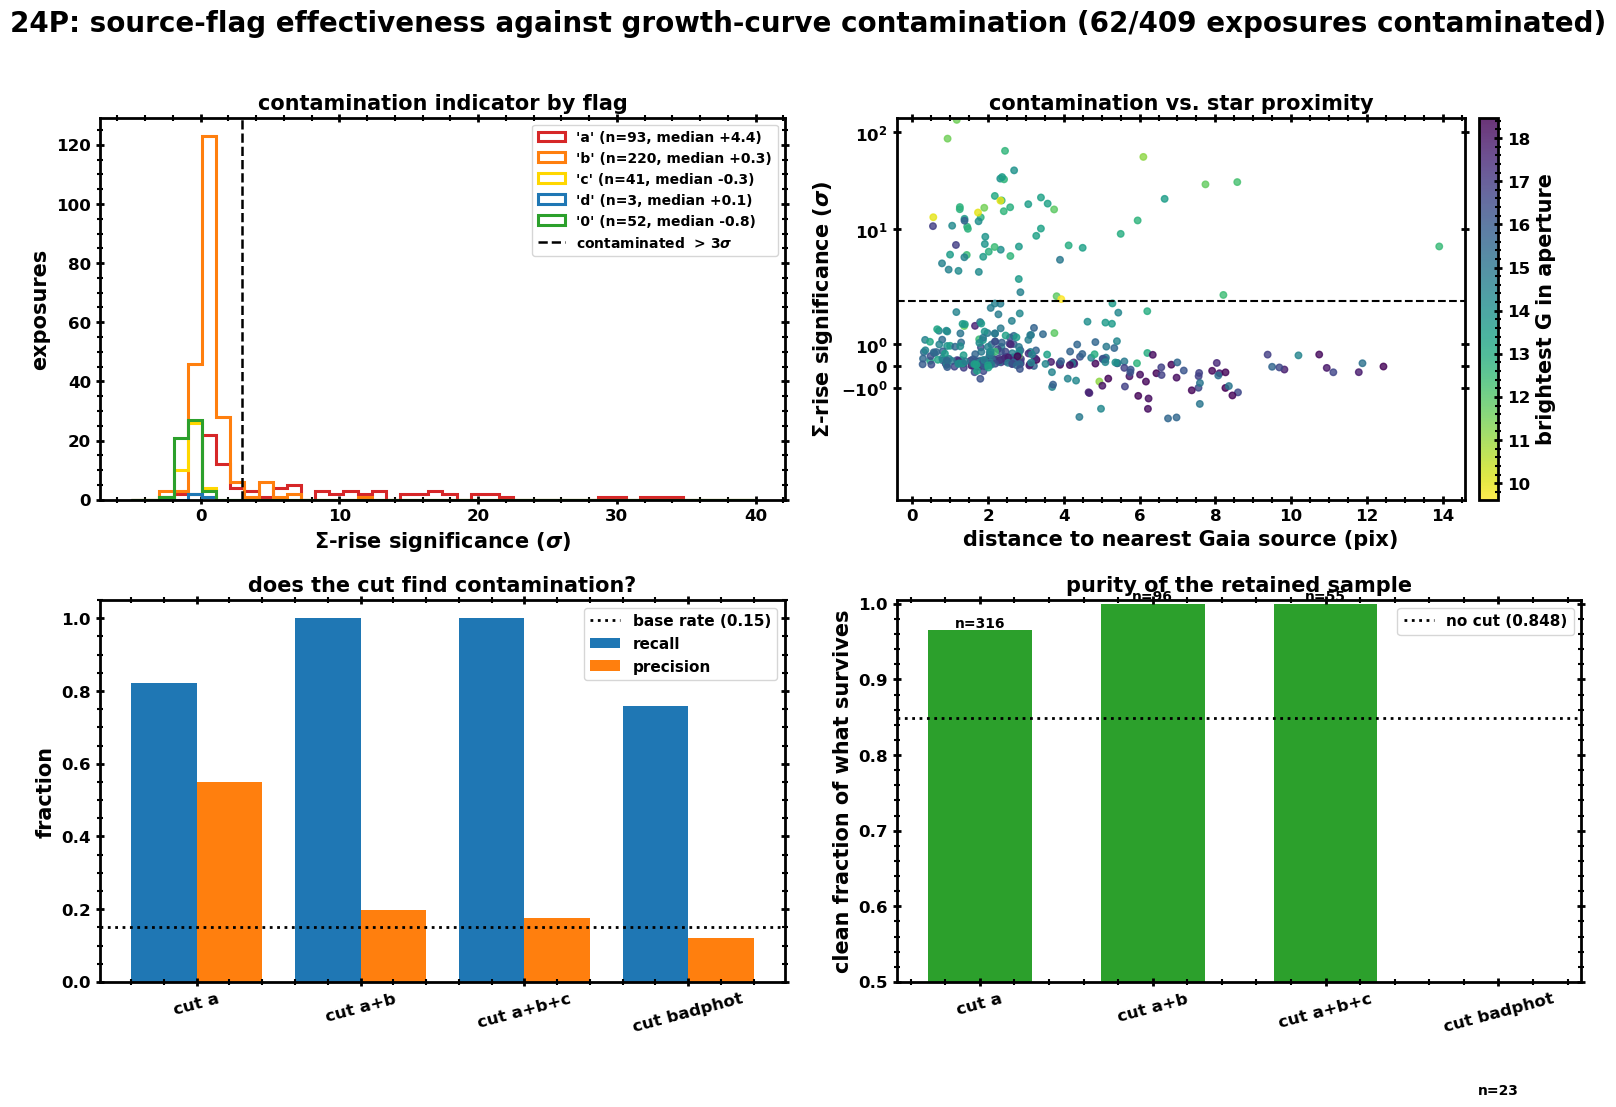

In [23]:
fig = plotting.plot_contamination_analysis(metrics, threshold=3.0, objdesig=TARGET)
plt.show()

In [24]:
# Is the conclusion sensitive to the 3-sigma choice?
rows = []
for thr in (2.0, 3.0, 5.0, 10.0):
    e = flag_effectiveness(metrics, threshold=thr)
    for cut in ("cut a", "cut a+b", "cut a+b+c"):
        r = e[e.cut == cut].iloc[0]
        rows.append({"threshold": thr, "cut": cut, "recall": r["recall"],
                     "precision": r["precision"],
                     "lift": r["precision"] / e.attrs["base_rate"],
                     "purity_kept": r["purity_kept"]})
pd.DataFrame(rows).pivot(index="cut", columns="threshold",
                         values=["recall", "precision", "lift"]).round(3)

recall                      precision                        lift  \
threshold   2.0    3.0    5.0    10.0      2.0    3.0    5.0    10.0   2.0    
cut                                                                           
cut a      0.737  0.823  0.885  0.971     0.602  0.548  0.495  0.366  3.241   
cut a+b    1.000  1.000  1.000  1.000     0.243  0.198  0.166  0.112  1.307   
cut a+b+c  1.000  1.000  1.000  1.000     0.215  0.175  0.147  0.099  1.155   

                                
threshold   3.0    5.0    10.0  
cut                             
cut a      3.618  3.890  4.272  
cut a+b    1.307  1.307  1.307  
cut a+b+c  1.155  1.155  1.155

**How to read this.**  `lift` is precision divided by the base contamination
rate: greater than 1 means the cut preferentially removes contaminated
exposures, ~1 means it is uncorrelated with contamination and is throwing away
good data for nothing.  `purity_kept` is what actually matters for a science
sample — the clean fraction of what survives the cut — and should be compared
with the no-cut value printed above the table.

## 10. Spectra by flag

Wavelength against the **distance-corrected flux**, with a distinct marker per
flag so contamination is visible in the spectrum itself rather than hidden in a
column.  `badphot` takes precedence over any contamination flag: it is a
data-quality failure, not a contamination warning.

363 measurements, 0.74-5.01 um


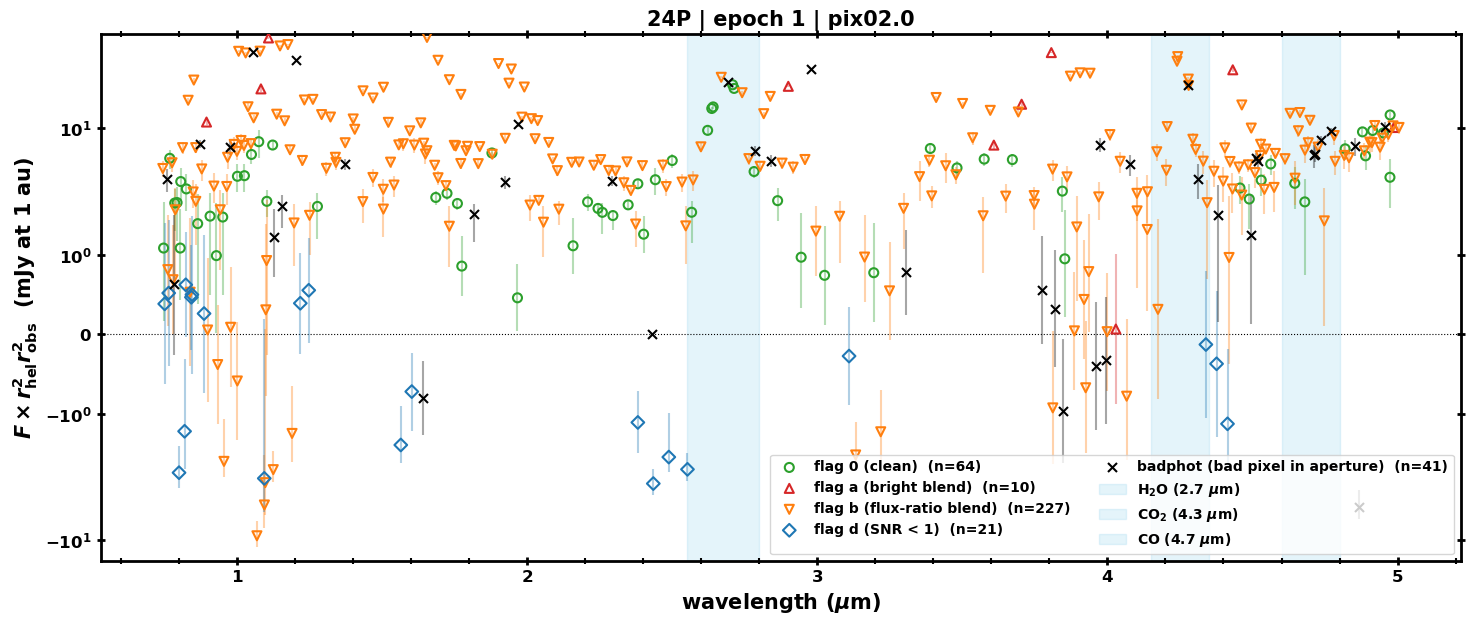

In [25]:
EPOCH = int(phot.epoch.min())
spec = phot[(phot.ap_label == AP) & (phot.epoch == EPOCH)].copy()
print(f"{len(spec)} measurements, {spec.wl.min():.2f}-{spec.wl.max():.2f} um")

fig = plotting.plot_spectrum_by_flag(spec, objdesig=TARGET, epoch=EPOCH, logy=True)
plt.show()

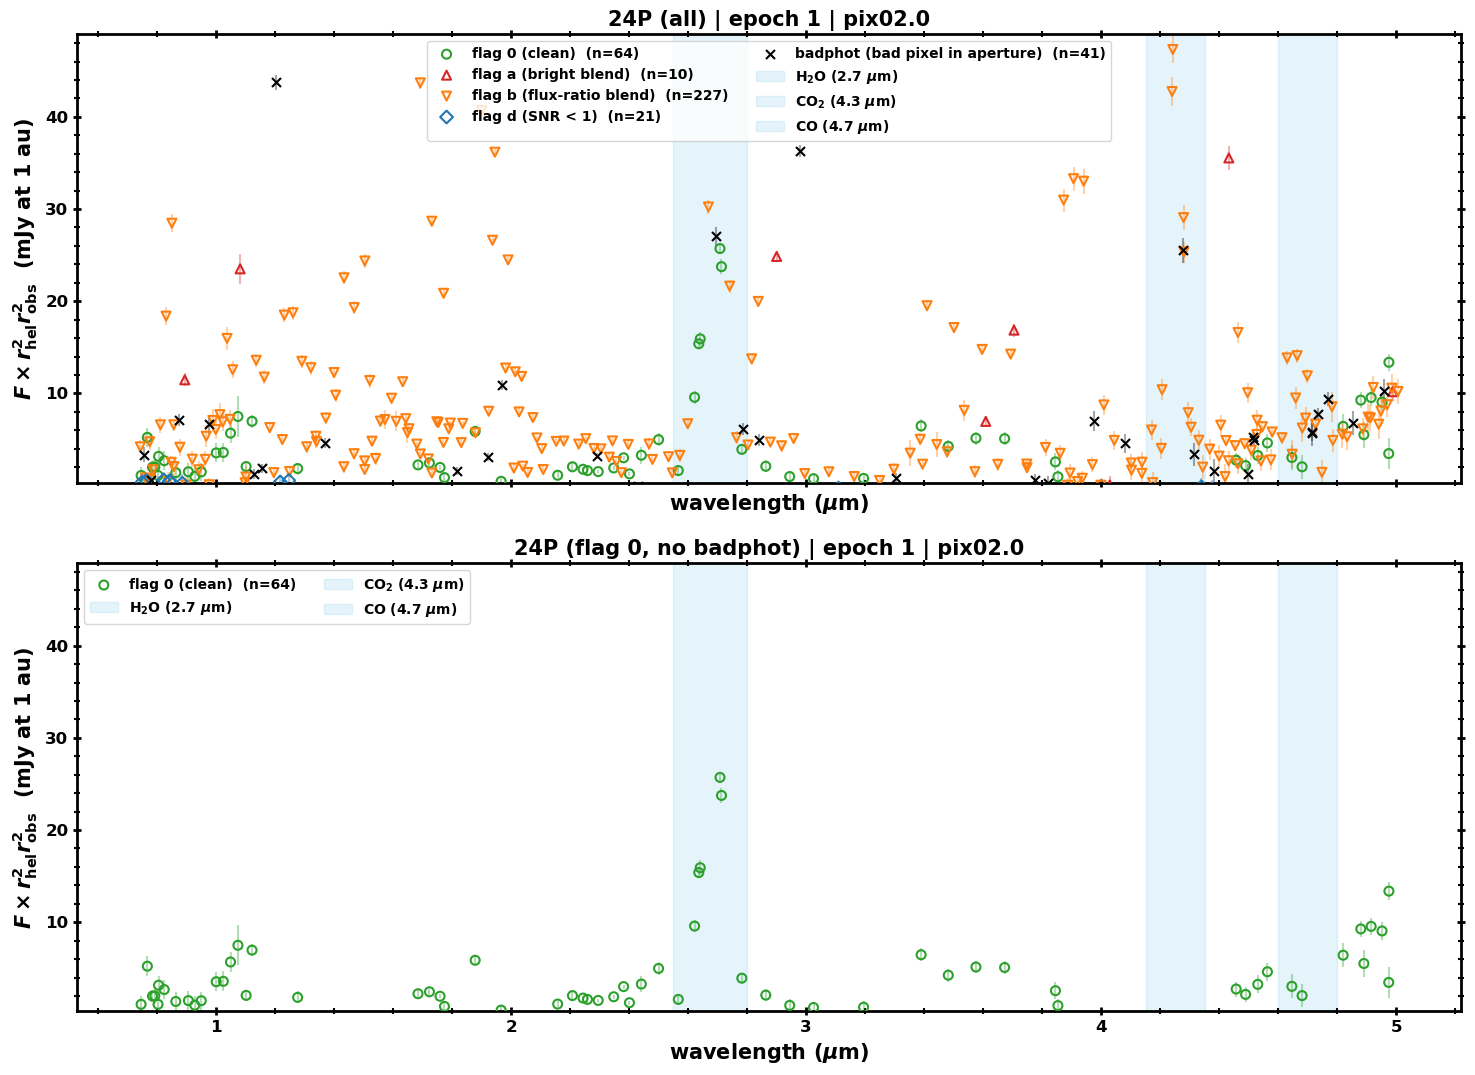

kept 64/363 points (18 %); scatter 11.7 -> 4.99


In [26]:
# Same spectrum, clean points only -- what the flags buy you.
clean = spec[(spec.sourceflag == "0") & ~spec.badphot]
fig, axes = plt.subplots(2, 1, figsize=(15, 11), sharex=True)
plotting.plot_spectrum_by_flag(spec, objdesig=f"{TARGET} (all)", epoch=EPOCH, ax=axes[0])
plotting.plot_spectrum_by_flag(clean, objdesig=f"{TARGET} (flag 0, no badphot)",
                               epoch=EPOCH, ax=axes[1])
for ax in axes:
    ax.set_ylim(np.nanpercentile(clean.flux_distcorr_mjy, [1, 99]) * np.array([0.5, 2.0]))
plt.tight_layout(); plt.show()
print(f"kept {len(clean)}/{len(spec)} points ({100*len(clean)/len(spec):.0f} %); "
      f"scatter {spec.flux_distcorr_mjy.std():.3g} -> {clean.flux_distcorr_mjy.std():.3g}")

### Does the distance correction do its job?

24P was at $r_{\rm hel}=1.79$ au in epoch 1 and $1.20$ au in epoch 2, and closer
still to the observer, so its raw flux differs enormously between them.  If
`flux_distcorr` is right, most of that gap should close — and whatever is left is
the comet genuinely brightening toward perihelion, not geometry.

,n,r_hel,r_obs,raw_median,corrected_median,raw_ratio,corrected_ratio
epoch,,,,,,,
1,64,1.793,1.535,0.409,2.722,1.000,1.000
2,318,1.199,0.604,26.192,14.085,63.993,5.174


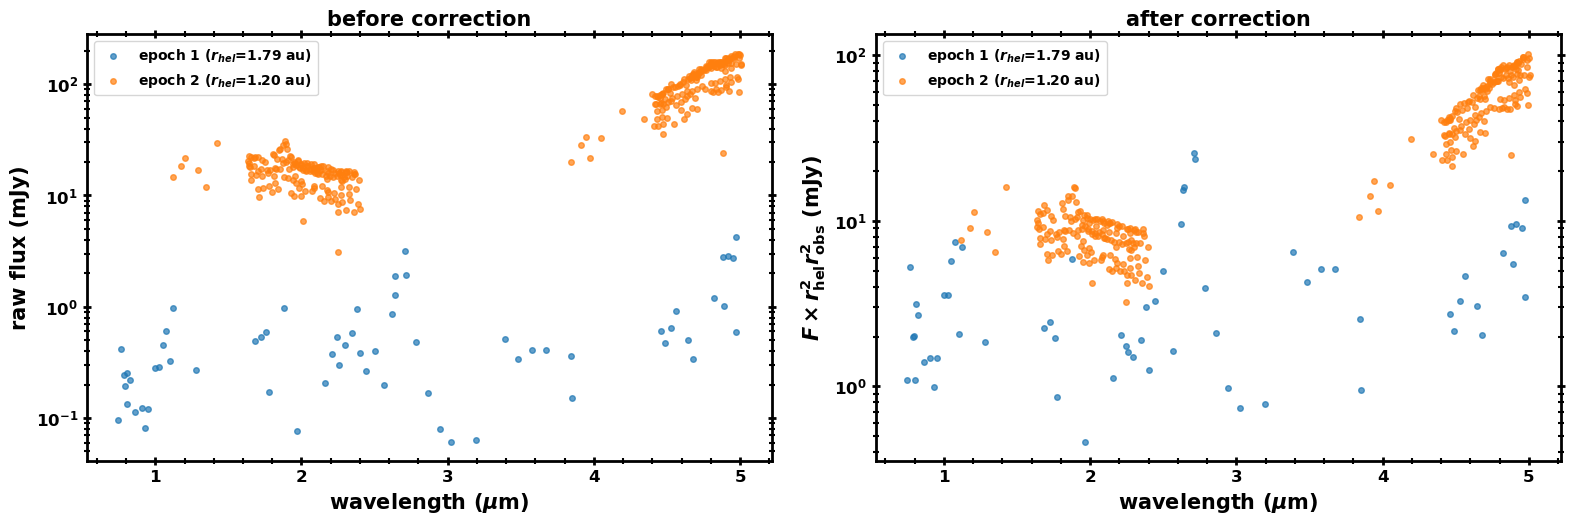

epoch-to-epoch median ratio: 64.0x raw  ->  5.2x corrected


In [27]:
sel = (phot.ap_label == AP) & (phot.sourceflag == "0") & ~phot.badphot
d = phot[sel]
summary = d.groupby("epoch").agg(
    n=("wl", "size"), r_hel=("r_hel", "mean"), r_obs=("r_obs", "mean"),
    raw_median=("source_sum_mjy", "median"),
    corrected_median=("flux_distcorr_mjy", "median"))
summary["raw_ratio"] = summary.raw_median / summary.raw_median.iloc[0]
summary["corrected_ratio"] = summary.corrected_median / summary.corrected_median.iloc[0]
display(summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharex=True)
for ax, col, name in zip(axes, ["source_sum_mjy", "flux_distcorr_mjy"],
                         ["raw flux (mJy)", r"$F \times r_{\rm hel}^2 r_{\rm obs}^2$ (mJy)"]):
    for ep in sorted(d.epoch.unique()):
        e = d[d.epoch == ep]
        ax.scatter(e.wl, e[col], s=16, alpha=0.7,
                   label=f"epoch {ep} ($r_{{hel}}$={e.r_hel.mean():.2f} au)")
    ax.set_yscale("log"); ax.set_xlabel(r"wavelength ($\mu$m)")
    ax.set_ylabel(name); ax.legend(fontsize=10)
axes[0].set_title("before correction"); axes[1].set_title("after correction")
plt.tight_layout(); plt.show()

print(f"epoch-to-epoch median ratio: {summary.raw_ratio.iloc[-1]:.1f}x raw  ->  "
      f"{summary.corrected_ratio.iloc[-1]:.1f}x corrected")

## 11. Reflectance

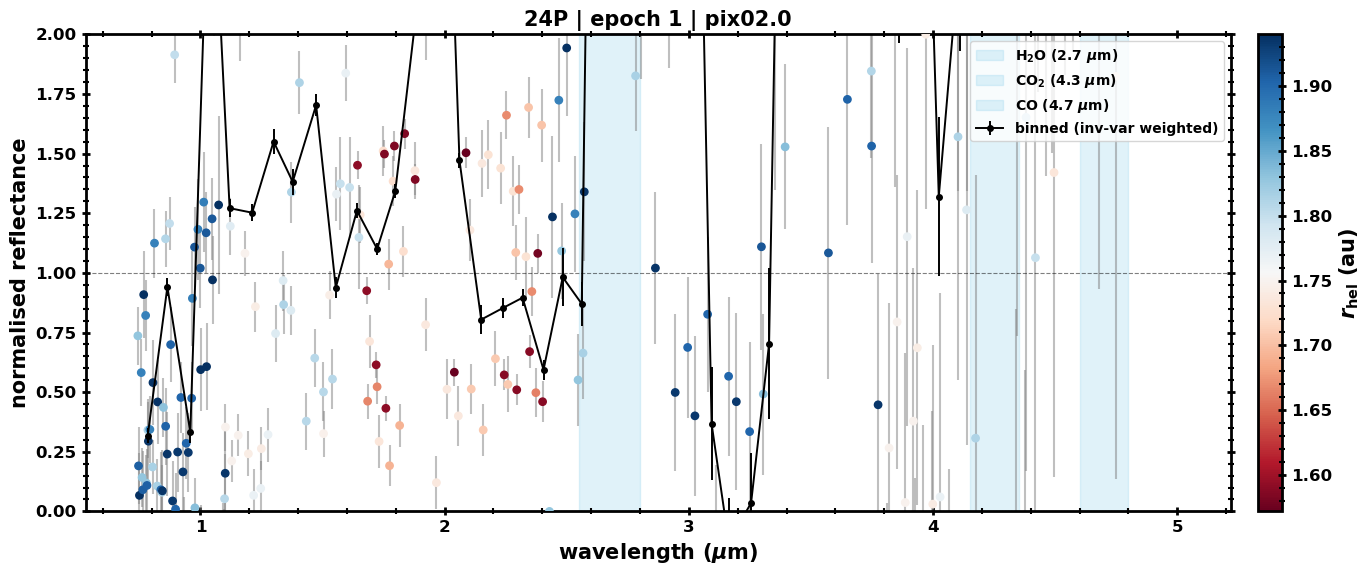

In [28]:
from spherex_apphot.reflectance import (add_reflectance, bin_spectrum,
                                        normalise_reflectance)

refl = normalise_reflectance(add_reflectance(phot, cfg), cfg)
sub = refl[(refl.ap_label == AP) & (refl.epoch == EPOCH)]
rbin = bin_spectrum(sub, value_col="refl_norm", err_col="refl_norm_err", n_bins=50)

fig = plotting.plot_reflectance(sub, objdesig=TARGET, epoch=EPOCH, binned=rbin)
plt.show()

Reflectance is $F_{obs}/F_\odot \times r_{hel}^2 r_{obs}^2$ — note this
**multiplies**, which is what puts different epochs on a common scale.  The
distance factors were missing entirely from the prototype (review item **S11**).
Normalisation uses an inverse-variance weighted, sigma-clipped mean over a
continuum window (`cfg.refl_norm_window_um`, default 1.0–2.5 µm) chosen to avoid
the 2.7 µm water band, and the uncertainty of the normalisation constant itself
is propagated.

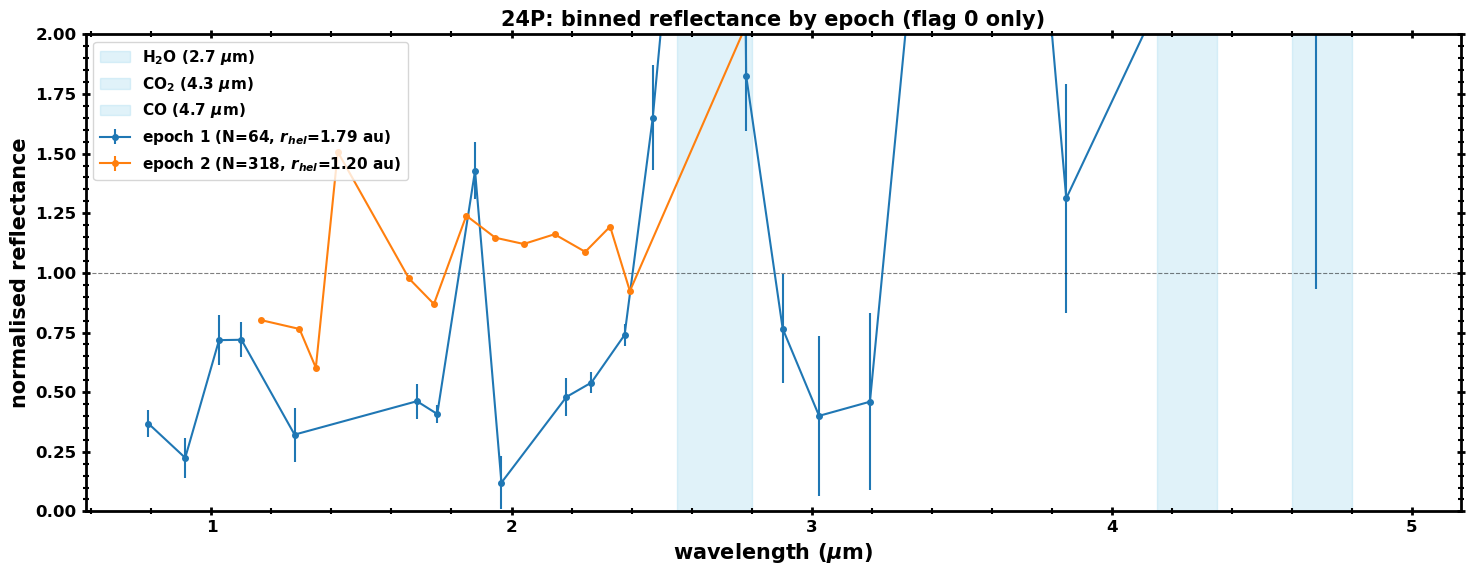

In [29]:
fig, ax = plt.subplots(figsize=(15, 6))
for ep in sorted(refl.epoch.unique()):
    s = refl[(refl.ap_label == AP) & (refl.epoch == ep) &
             (refl.sourceflag == "0") & ~refl.badphot]
    b = bin_spectrum(s, value_col="refl_norm", err_col="refl_norm_err", n_bins=40)
    if len(b):
        ax.errorbar(b.wl, b.value, yerr=b.error, marker="o", lw=1.5, ms=4,
                    label=f"epoch {ep} (N={len(s)}, $r_{{hel}}$={s.r_hel.mean():.2f} au)")
for label, lo, hi in plotting.VOLATILE_BANDS:
    ax.axvspan(lo, hi, color="skyblue", alpha=0.25, zorder=0, label=label)
ax.axhline(1.0, color="k", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel(r"wavelength ($\mu$m)"); ax.set_ylabel("normalised reflectance")
ax.set_title(f"{TARGET}: binned reflectance by epoch (flag 0 only)"); ax.set_ylim(0, 2)
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

## 12. Band stacking and radial profiles

In [30]:
stacks = stack_target(phot, cfg, objdesig=TARGET, ap_label=AP, write=True)
print(f"{len(stacks)} stack(s), combined with the sigma-clipped {cfg.stack_combine}:")
for (ep, band), r in sorted(stacks.items()):
    print(f"  epoch {ep:>2}  {band:<14s} N={r.n_frames:>3}  {r.shape}")

2026-09-07 04:00:52 INFO    spherex_apphot.pipeline: stacking 24P using the pix02.0 aperture for sky levels


2026-09-07 04:00:53 INFO    spherex_apphot.stacking: stack written: 24P_epoch1_Continuum.fits (60 frames)


2026-09-07 04:00:53 INFO    spherex_apphot.stacking: stack written: 24P_epoch1_H2O.fits (15 frames)


2026-09-07 04:00:53 INFO    spherex_apphot.stacking: stack written: 24P_epoch1_H2O_ICE.fits (21 frames)


2026-09-07 04:00:53 INFO    spherex_apphot.stacking: stack written: 24P_epoch1_CO2.fits (15 frames)


2026-09-07 04:00:53 INFO    spherex_apphot.stacking: stack written: 24P_epoch1_CO.fits (18 frames)


2026-09-07 04:00:53 INFO    spherex_apphot.stacking: stack written: 24P_epoch2_Continuum.fits (90 frames)


2026-09-07 04:00:53 INFO    spherex_apphot.stacking: stack written: 24P_epoch2_CO2.fits (3 frames)


2026-09-07 04:00:54 INFO    spherex_apphot.stacking: stack written: 24P_epoch2_CO.fits (63 frames)


8 stack(s), combined with the sigma-clipped median:
  epoch  1  CO             N= 18  (51, 51)
  epoch  1  CO2            N= 15  (51, 51)
  epoch  1  Continuum      N= 60  (51, 51)
  epoch  1  H2O            N= 15  (51, 51)
  epoch  1  H2O_ICE        N= 21  (51, 51)
  epoch  2  CO             N= 63  (51, 51)
  epoch  2  CO2            N=  3  (51, 51)
  epoch  2  Continuum      N= 90  (51, 51)


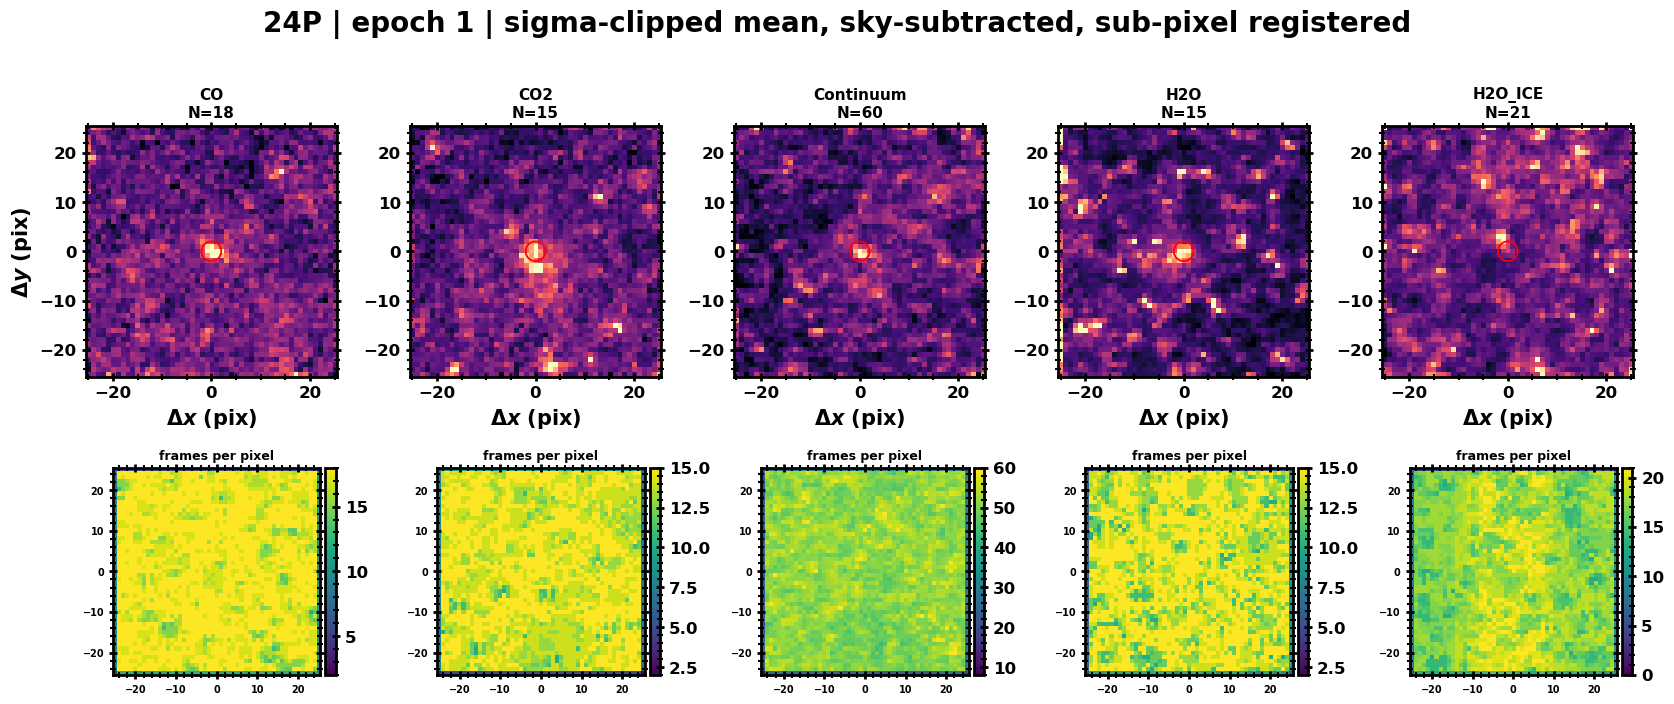

In [31]:
fig = plotting.plot_stacks(stacks, objdesig=TARGET, epoch=EPOCH, cfg=cfg)
plt.show()

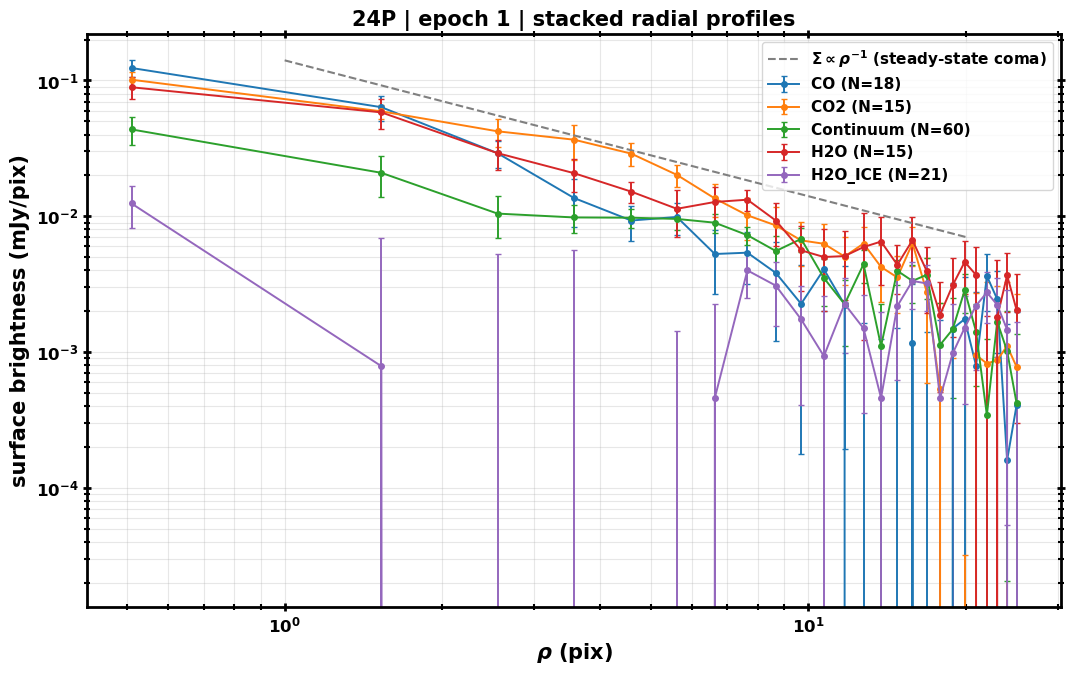

In [32]:
fig = plotting.plot_radial_profile(stacks, objdesig=TARGET, epoch=EPOCH)
plt.show()

Each frame is background-subtracted with its own annulus median, registered to a
common sub-pixel centre, and combined with a sigma-clipped **median**; the count
map below each panel shows how many frames survived at each pixel.

The median matters more than it looks.  Sigma clipping alone does not remove a
star that lands at the same stamp position in a *minority* of frames — with 2
contaminated frames out of 10 a clipped mean still returns ~100 where the truth
is 0, while the median returns ~0.  In a crowded field like 24P's that is the
difference between a stack of the comet and a stack of its neighbours.

On the radial profile, a canonical steady-state coma is a straight line of slope
−1 in log–log; the grey dashed line is that reference.

## 13. Saving the figure set

Two figures per cutout (three-panel view + growth curve) and a handful per
target.  `scripts/apphot/main.py` writes none of these — plotting is a notebook/analysis step by
design.

Per-cutout output is capped below so the notebook stays quick.  For the complete
set, use the dedicated CLI — it is the same code, and it keeps a long render out
of the notebook:

```bash
python scripts/apphot/make_figures.py --sample --objdesig 2P 24P
```

That writes 2 figures per exposure (1 982 PNGs for these two targets, ~7 minutes)
plus the per-target summaries.  Batch figures use `dpi=50` per the project
convention; the per-target summaries use 200.

In [33]:
MAX_CUTOUT_FIGS = 6          # set to None to write every exposure

paths = plotting.save_cutout_figures(
    phot, resolver, cfg, gaia_subset=subset, objdesig=TARGET,
    ap_label=AP, max_cutouts=MAX_CUTOUT_FIGS, dpi=50)
print(f"{len(paths)} per-cutout figures -> {paths[0].parent}")
for p in paths[:4]:
    print("   ", p.name)

2026-09-07 04:00:56 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/cutouts/24P_0.7505um_18.84Vmag_2025W36_2B_0131_3_1_cutout.png


2026-09-07 04:00:56 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/cutouts/24P_0.7505um_18.84Vmag_2025W36_2B_0131_3_1_growth.png


2026-09-07 04:00:57 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/cutouts/24P_2.4417um_18.84Vmag_2025W36_2B_0131_3_4_cutout.png


2026-09-07 04:00:57 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/cutouts/24P_2.4417um_18.84Vmag_2025W36_2B_0131_3_4_growth.png


2026-09-07 04:00:58 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/cutouts/24P_0.7679um_18.84Vmag_2025W36_2B_0131_4_1_cutout.png


...

2026-09-07 04:01:00 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/cutouts/24P_3.3895um_18.84Vmag_2025W36_2B_0157_1_4_growth.png


2026-09-07 04:01:00 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/cutouts/24P_1.0011um_18.84Vmag_2025W36_2B_0157_1_1_cutout.png


2026-09-07 04:01:01 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/cutouts/24P_1.0011um_18.84Vmag_2025W36_2B_0157_1_1_growth.png


2026-09-07 04:01:01 INFO    spherex_apphot.plotting: wrote 12 per-cutout figures to /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/cutouts


12 per-cutout figures -> /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/cutouts
    24P_0.7505um_18.84Vmag_2025W36_2B_0131_3_1_cutout.png
    24P_0.7505um_18.84Vmag_2025W36_2B_0131_3_1_growth.png
    24P_2.4417um_18.84Vmag_2025W36_2B_0131_3_4_cutout.png
    24P_2.4417um_18.84Vmag_2025W36_2B_0131_3_4_growth.png


In [34]:
target_figs = plotting.save_target_figures(
    phot, cfg, objdesig=TARGET, stacks=stacks, metrics=metrics, ap_label=AP, dpi=200)
print(f"{len(target_figs)} per-target figures -> {target_figs[0].parent}")
for p in target_figs:
    print("   ", p.name)

2026-09-07 04:01:01 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/spectrum_24P_epoch1.png


2026-09-07 04:01:02 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/reflectance_24P_epoch1.png


2026-09-07 04:01:03 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/stacks_24P_epoch1.png


2026-09-07 04:01:03 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/radialprofile_24P_epoch1.png


2026-09-07 04:01:04 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/spectrum_24P_epoch2.png


...

2026-09-07 04:01:06 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/contamination_24P.png


2026-09-07 04:01:07 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/sourceflags_24P.png


2026-09-07 04:01:07 INFO    spherex_apphot.plotting: figure written: /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P/apertures_24P.png


2026-09-07 04:01:07 INFO    spherex_apphot.plotting: wrote 11 target figures to /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P


11 per-target figures -> /Users/bumhoo7/Desktop/claude/spherex-comet-apphot/fig/24P
    spectrum_24P_epoch1.png
    reflectance_24P_epoch1.png
    stacks_24P_epoch1.png
    radialprofile_24P_epoch1.png
    spectrum_24P_epoch2.png
    reflectance_24P_epoch2.png
    stacks_24P_epoch2.png
    radialprofile_24P_epoch2.png
    contamination_24P.png
    sourceflags_24P.png
    apertures_24P.png


## 14. Provenance and the status log

In [35]:
import json
meta = json.loads((directory.APPHOT_DIR / f"{res.slug}.meta.json").read_text())
print(f"written  : {meta['written_utc']}")
print(f"rows     : {meta['n_rows']}")
print(f"flux unit: {meta['flux_unit']}")
print(f"cfg hash : {meta['config_hash']}")
print("\nevery parameter that produced this file is in meta['config']:")
print(json.dumps({k: meta["config"][k] for k in
                  ["r_in_pix", "r_out_pix", "sky_noise_mode", "stack_combine",
                   "distcorr_mode", "sourceflag_bright_gmag",
                   "sourceflag_bright_psf_mult", "sourceflag_b_flux_frac"]}, indent=2))

written  : 2026-09-06T19:00:46Z
rows     : 14526
flux unit: mJy/pixel
cfg hash : 5502194856bc

every parameter that produced this file is in meta['config']:
{
  "r_in_pix": 15.0,
  "r_out_pix": 20.0,
  "sky_noise_mode": "level",
  "stack_combine": "median",
  "distcorr_mode": "multiply",
  "sourceflag_bright_gmag": 13.0,
  "sourceflag_bright_psf_mult": 2.0,
  "sourceflag_b_flux_frac": 0.2
}


In [36]:
StatusLog(directory.STATUS_CSV).read()[
    ["objdesig", "slug", "status", "timestamp", "elapsed_s", "n_exposures",
     "n_rows_out", "n_missing_fits", "n_ap_skipped", "n_badphot", "config_hash"]]

,objdesig,slug,status,timestamp,elapsed_s,n_exposures,n_rows_out,n_missing_fits,n_ap_skipped,n_badphot,config_hash
0,10P,10P,ok,2026-09-06T14:56:44Z,62.47,289.0,5884.0,0.0,185.0,2449.0,5502194856bc
1,124P,124P,ok,2026-09-06T14:57:47Z,48.44,377.0,7606.0,0.0,311.0,2799.0,5502194856bc
2,131P,131P,ok,2026-09-06T14:57:21Z,19.71,331.0,6719.0,0.0,232.0,1385.0,5502194856bc
3,145P,145P,ok,2026-09-06T14:57:55Z,43.60,336.0,6858.0,0.0,198.0,1841.0,5502194856bc
4,161P,161P,ok,2026-09-06T14:58:18Z,63.94,994.0,16454.0,0.0,4420.0,3599.0,5502194856bc
...,...,...,...,...,...,...,...,...,...,...,...
63,493P,493P,ok,2026-09-06T15:01:28Z,29.49,263.0,4706.0,0.0,817.0,1430.0,5502194856bc
64,499P,499P,ok,2026-09-06T15:02:32Z,90.83,392.0,7233.0,0.0,999.0,3612.0,5502194856bc
65,508P,508P,ok,2026-09-06T15:03:12Z,126.01,210.0,4000.0,0.0,410.0,2060.0,5502194856bc
66,63P,63P,ok,2026-09-06T14:57:10Z,25.56,328.0,6548.0,0.0,340.0,2000.0,5502194856bc


`results/apphot/status.csv` is what the batch driver consults to decide whether a target
can be skipped, and both the writer and that check go through `slugify()` — the
single definition of a target's filesystem name.  The prototype wrote
`2021G2.csv` but looked for `2021 G2.csv`, so every target whose designation
contains a space (most comets) was silently reprocessed on every run
(review item **R1**).

### Running the batch

```bash
# one target
python scripts/apphot/main.py --objdesig 24P

# everything, four at a time, resuming from status.csv
python scripts/apphot/main.py --all --workers 4

# one-off: build the Gaia declination cache (~5 min, ~8 GB)
python scripts/apphot/build_gaia_cache.py
```